# Understanding the Opioid Crisis: An Analysis of Overdose Trends Across States, Demographics, and Drug Types

Author: Alissa N. Beaderstadt<br>
Northwest Missouri State University, Maryville MO 64468, USA<br>
Email: S528352@nwmissouri.edu and alissabeaderstadt@outlook.com<br>

## Project Overview

This notebook performs exploratory modeling on opioid overdose mortality data obtained from CDC WONDER. The analysis uses one primary state-by-year dataset containing overall opioid overdose deaths and opioid subtype deaths, to train three regression models linear regrssion, random forest, and gradient boosting. The objective is to confidently predict future opioid overdose mortality.

## Section 1. Imports

In [118]:
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Section 2. Load Cleaned Master Dataset
The cleaned master opioid overdose dataset is loaded from the processed data directory. Using the previously cleaned dataset ensures that the predictive modeling phase builds directly on the data preparation workflow without repeating the original data cleaning process.

In [119]:
# Define the path to the cleaned master dataset
DATA_PATH = Path("../data/processed/merged_opioid_deaths.csv")

# Load the cleaned dataset
analysis_df = pd.read_csv(DATA_PATH)

# Remove identifier columns not needed for analysis
analysis_df = analysis_df.drop(
    columns=["state_code", "year_code"]
)

# Preview the dataset
analysis_df.head()

,state,year,opioid_deaths,population,opioid_death_rate,heroin_deaths,heroin_death_rate,other_deaths,other_death_rate,methadone_deaths,methadone_death_rate,synthetic_deaths,synthetic_death_rate,prescription_deaths,prescription_death_rate
0,Alabama,1999,26.0,4430141.0,0.6,NaN,NaN,NaN,NaN,14.0,NaN,NaN,NaN,NaN,NaN
1,Alabama,2000,31.0,4447100.0,0.7,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,NaN
2,Alabama,2001,47.0,4467634.0,1.1,NaN,NaN,NaN,NaN,22.0,0.5,NaN,NaN,19.0,NaN
3,Alabama,2002,61.0,4480089.0,1.4,NaN,NaN,NaN,NaN,30.0,0.7,NaN,NaN,26.0,0.6
4,Alabama,2003,40.0,4503491.0,0.9,NaN,NaN,NaN,NaN,23.0,0.5,NaN,NaN,18.0,NaN


## Section 3. Inspect Cleaned Data
The dataset is reviewed to confirm its dimensions, column names, data types, and missing values before modeling begins. This step verifies that the expected processed dataset was loaded correctly and helps identify any issues that could affect the predictive analysis.

In [120]:
# Display the shape of the dataset
print("Dataset shape:", analysis_df.shape)

# Display column names
print("\nColumns:")
print(analysis_df.columns.tolist())

# Display dataset information
print("\nDataset information:")
analysis_df.info()

Dataset shape: (1122, 15)

Columns:
['state', 'year', 'opioid_deaths', 'population', 'opioid_death_rate', 'heroin_deaths', 'heroin_death_rate', 'other_deaths', 'other_death_rate', 'methadone_deaths', 'methadone_death_rate', 'synthetic_deaths', 'synthetic_death_rate', 'prescription_deaths', 'prescription_death_rate']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   state                    1122 non-null   str    
 1   year                     1122 non-null   int64  
 2   opioid_deaths            1085 non-null   float64
 3   population               1122 non-null   float64
 4   opioid_death_rate        1040 non-null   float64
 5   heroin_deaths            811 non-null    float64
 6   heroin_death_rate        661 non-null    float64
 7   other_deaths             740 non-null    float64
 8   other_death_rate   

In [121]:
# Review missing values
missing_values = analysis_df.isna().sum().sort_values(ascending=False)

missing_values

other_death_rate           604
synthetic_death_rate       479
heroin_death_rate          461
methadone_death_rate       390
other_deaths               382
heroin_deaths              311
synthetic_deaths           264
prescription_death_rate    231
methadone_deaths           209
prescription_deaths        109
opioid_death_rate           82
opioid_deaths               37
population                   0
state                        0
year                         0
dtype: int64

## Section 4. Create Lagged and Next-Year Features
The data is sorted by state and year, and time-based features are created to represent each state's previous-year and next-year opioid death rates. These features allow historical opioid mortality patterns to be used to predict the opioid death rate for the following year.

In [122]:
# Sort the data by state and year before creating time-based features
model_df = analysis_df.sort_values(["state", "year"]).copy()

# Create previous-year opioid death rate
model_df["previous_year_opioid_death_rate"] = (
    model_df.groupby("state")["opioid_death_rate"].shift(1)
)

# Create next-year opioid death rate
model_df["next_year_opioid_death_rate"] = (
    model_df.groupby("state")["opioid_death_rate"].shift(-1)
)

# Create previous-year and next-year identifiers
model_df["previous_year"] = model_df.groupby("state")["year"].shift(1)
model_df["next_year"] = model_df.groupby("state")["year"].shift(-1)

# Keep lagged values only when observations are truly consecutive years
model_df.loc[
    model_df["previous_year"] != model_df["year"] - 1,
    "previous_year_opioid_death_rate"
] = pd.NA

model_df.loc[
    model_df["next_year"] != model_df["year"] + 1,
    "next_year_opioid_death_rate"
] = pd.NA

# Preview the engineered features
model_df[
    [
        "state",
        "year",
        "previous_year_opioid_death_rate",
        "opioid_death_rate",
        "next_year_opioid_death_rate",
    ]
].head(15)

,state,year,previous_year_opioid_death_rate,opioid_death_rate,next_year_opioid_death_rate
0,Alabama,1999,NaN,0.6,0.7
1,Alabama,2000,0.6,0.7,1.1
2,Alabama,2001,0.7,1.1,1.4
3,Alabama,2002,1.1,1.4,0.9
4,Alabama,2003,1.4,0.9,1.7
5,Alabama,2004,0.9,1.7,1.4
6,Alabama,2005,1.7,1.4,2.1
7,Alabama,2006,1.4,2.1,3.1
8,Alabama,2007,2.1,3.1,3.3
9,Alabama,2008,3.1,3.3,3.7


## Section 5. Define Predictors and Target
The predictor variables include the year, current opioid death rate, and previous-year opioid death rate. The target variable is the next-year opioid death rate, allowing the models to evaluate whether recent mortality patterns can predict opioid mortality one year into the future.

In [123]:
# Define predictor variables
features = [
    "year",
    "opioid_death_rate",
    "previous_year_opioid_death_rate",
]

# Define the prediction target
target = "next_year_opioid_death_rate"

## Section 6. Prepare Modeling Dataset
The modeling dataset is created using only the variables required for prediction, and observations missing any required predictor or target values are removed. This ensures that all observations used for model training and evaluation contain complete information for the selected variables.

In [124]:
# Create the modeling dataset
modeling_data = model_df[
    ["state"] + features + [target]
].copy()

# Remove rows missing any required modeling values
modeling_data = modeling_data.dropna(
    subset=features + [target]
)

# Review the resulting dataset
print("Original dataset rows:", len(analysis_df))
print("Modeling dataset rows:", len(modeling_data))
print("Rows removed:", len(analysis_df) - len(modeling_data))

print(
    "Percent retained:",
    round(len(modeling_data) / len(analysis_df) * 100, 2),
    "%"
)

modeling_data.head()

Original dataset rows: 1122
Modeling dataset rows: 927
Rows removed: 195
Percent retained: 82.62 %


,state,year,opioid_death_rate,previous_year_opioid_death_rate,next_year_opioid_death_rate
1,Alabama,2000,0.7,0.6,1.1
2,Alabama,2001,1.1,0.7,1.4
3,Alabama,2002,1.4,1.1,0.9
4,Alabama,2003,0.9,1.4,1.7
5,Alabama,2004,1.7,0.9,1.4


In [125]:
# Review available observations by year
modeling_data.groupby("year").size()

year
2000    33
2001    35
2002    40
2003    43
2004    44
2005    44
2006    46
2007    47
2008    47
2009    48
2010    48
2011    49
2012    49
2013    49
2014    50
2015    51
2016    51
2017    51
2018    51
2019    51
dtype: int64

In [126]:
print("Minimum modeling year:", modeling_data["year"].min())
print("Maximum modeling year:", modeling_data["year"].max())

Minimum modeling year: 2000
Maximum modeling year: 2019


## Section 7. Create Time-Based Train/Test Split
The modeling data is divided chronologically, with observations through 2017 used for training and later observations reserved for testing. A time-based split better represents a real-world forecasting scenario by training models on historical data and evaluating their ability to predict later, unseen outcomes.

In [127]:
# Define the final predictor year used for training
TRAIN_END_YEAR = 2017

# Create time-based training and testing datasets
train_df = modeling_data[
    modeling_data["year"] <= TRAIN_END_YEAR
].copy()

test_df = modeling_data[
    modeling_data["year"] > TRAIN_END_YEAR
].copy()

print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

print("\nTraining predictor years:")
print(sorted(train_df["year"].unique()))

print("\nTesting predictor years:")
print(sorted(test_df["year"].unique()))

Training observations: 825
Testing observations: 102

Training predictor years:
[np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Testing predictor years:
[np.int64(2018), np.int64(2019)]


In [128]:
# Separate predictors and target for training
X_train = train_df[features]
y_train = train_df[target]

# Separate predictors and target for testing
X_test = test_df[features]
y_test = test_df[target]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (825, 3)
X_test shape: (102, 3)
y_train shape: (825,)
y_test shape: (102,)


## Section 8. Create Time-Based Cross-Validation Splits
Time-based validation folds are created within the training data to support hyperparameter tuning without using the final test set. Each validation fold trains on earlier observations and validates on a later year, preserving the chronological structure of the data.

In [129]:
# Create time-based cross-validation splits using training data only
cv_splits = []

# Use the last four training years as validation years
validation_years = [2014, 2015, 2016, 2017]

for validation_year in validation_years:

    # Train only on years before the validation year
    train_indices = train_df.index[
        train_df["year"] < validation_year
    ]

    # Validate on the selected validation year
    validation_indices = train_df.index[
        train_df["year"] == validation_year
    ]

    # Convert DataFrame indices to positional indices
    train_positions = train_df.index.get_indexer(train_indices)
    validation_positions = train_df.index.get_indexer(validation_indices)

    cv_splits.append(
        (train_positions, validation_positions)
    )

print("Number of time-based validation folds:", len(cv_splits))

Number of time-based validation folds: 4


## Section 9. Train Linear Regression
A Linear Regression model is trained using the complete training dataset as a baseline predictive model. This model provides a straightforward approach for evaluating the relationship between recent opioid mortality patterns and the following year's opioid death rate.

In [130]:
# Train Linear Regression model
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression training complete.")

Linear Regression training complete.


## Section 10. Tune Random Forest
Random Forest hyperparameters are evaluated using time-based cross-validation within the training data. This process identifies a combination of model settings that performs well on later validation periods without using information from the final test set.

In [131]:
# Define Random Forest model
random_forest = RandomForestRegressor(
    random_state=42
)

# Define hyperparameter grid
random_forest_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

# Perform time-based hyperparameter tuning
random_forest_search = GridSearchCV(
    estimator=random_forest,
    param_grid=random_forest_params,
    scoring="neg_mean_squared_error",
    cv=cv_splits,
    n_jobs=-1,
)

random_forest_search.fit(
    X_train,
    y_train
)

# Save the best tuned model
best_random_forest = random_forest_search.best_estimator_

print("Best Random Forest parameters:")
print(random_forest_search.best_params_)

Best Random Forest parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


## Section 11. Tune Gradient Boosting
Gradient Boosting hyperparameters are also tuned using the time-based validation folds. This allows the model to be optimized using only the training data and provides a fair comparison with Linear Regression and Random Forest.

In [132]:
# Define Gradient Boosting model
gradient_boosting = GradientBoostingRegressor(
    random_state=42
)

# Define hyperparameter grid
gradient_boosting_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_split": [2, 5],
}

# Perform time-based hyperparameter tuning
gradient_boosting_search = GridSearchCV(
    estimator=gradient_boosting,
    param_grid=gradient_boosting_params,
    scoring="neg_mean_squared_error",
    cv=cv_splits,
    n_jobs=-1,
)

gradient_boosting_search.fit(
    X_train,
    y_train
)

# Save the best tuned model
best_gradient_boosting = gradient_boosting_search.best_estimator_

print("Best Gradient Boosting parameters:")
print(gradient_boosting_search.best_params_)

Best Gradient Boosting parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_split': 5, 'n_estimators': 100}


## Section 12. Create Final Model Dictionary
The trained Linear Regression model and the best-performing tuned versions of Random Forest and Gradient Boosting are stored together. Organizing the models in a dictionary allows all three algorithms to be evaluated consistently using the same test data and performance metrics.

In [133]:
# Store the final trained models
models = {
    "Linear Regression": linear_model,
    "Random Forest": best_random_forest,
    "Gradient Boosting": best_gradient_boosting,
}

## Section 13. Evaluate Models on Test Data
Each trained model is evaluated on the previously unseen test data using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R². Comparing these metrics helps determine which model most accurately predicts next-year opioid death rates.

In [134]:
# Store final model evaluation results
results = []

for name, model in models.items():

    # Generate predictions on the unseen test data
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )

    # Store results
    results.append(
        {
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
        }
    )

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Sort from lowest to highest RMSE
results_df = results_df.sort_values(
    "RMSE"
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,2.910740,4.485030,0.826352
1,Gradient Boosting,3.175714,4.908379,0.792023
2,Random Forest,3.214292,4.934068,0.789841


## Section 14. Identify Best Model
The model with the lowest RMSE is selected as the best-performing model for further analysis. This model is then used to generate predictions that can be compared directly with the actual next-year opioid death rates.

In [135]:
# Identify the model with the lowest RMSE
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best-performing model:", best_model_name)

Best-performing model: Linear Regression


## Section 15. Compare Actual vs. Predicted
Predictions from the best-performing model are combined with the actual opioid death rates and their corresponding predictor and target years. This comparison makes it possible to examine how closely the model's predictions match observed mortality rates for individual states.

In [136]:
# Generate predictions using the best-performing model
best_predictions = best_model.predict(X_test)

# Create a results DataFrame for comparison
prediction_results = test_df[
    ["state", "year", target]
].copy()

# Add the target year
prediction_results["target_year"] = (
    prediction_results["year"] + 1
)

# Add the predicted opioid death rates
prediction_results["predicted_opioid_death_rate"] = (
    best_predictions
)

# Reorder columns for readability
prediction_results = prediction_results[
    [
        "state",
        "year",
        "target_year",
        target,
        "predicted_opioid_death_rate",
    ]
]

prediction_results.head(10)

,state,year,target_year,next_year_opioid_death_rate,predicted_opioid_death_rate
19,Alabama,2018,2019,7.9,8.095972
20,Alabama,2019,2020,12.1,8.959433
41,Alaska,2018,2019,10.3,9.001401
42,Alaska,2019,2020,14.1,11.480454
63,Arizona,2018,2019,16.3,15.210638
64,Arizona,2019,2020,23.6,17.565793
85,Arkansas,2018,2019,5.8,6.582189
86,Arkansas,2019,2020,8.2,6.800480
107,California,2018,2019,7.6,6.690606
108,California,2019,2020,13.5,8.744628


# Section 16. Evaluate Prediction Error by Target Year
The mean absolute prediction error is calculated separately for each target year to determine whether model performance changes over time. This analysis helps identify whether the model had greater difficulty predicting the unusually large changes in opioid mortality observed in 2020.

In [137]:
# Evaluate whether the model performs noticeably worse for 2020 than for 2019
prediction_results["absolute_error"] = (
    prediction_results["next_year_opioid_death_rate"]
    - prediction_results["predicted_opioid_death_rate"]
).abs()

prediction_results.groupby("target_year")[
    "absolute_error"
].mean()

target_year
2019    1.359874
2020    4.461606
Name: absolute_error, dtype: float64

## Section 17. Visualize Results
An Actual vs. Predicted plot is used to visually compare the model's predicted opioid death rates with the observed rates in the test data. Predictions closer to the reference line indicate better agreement between predicted and actual values.

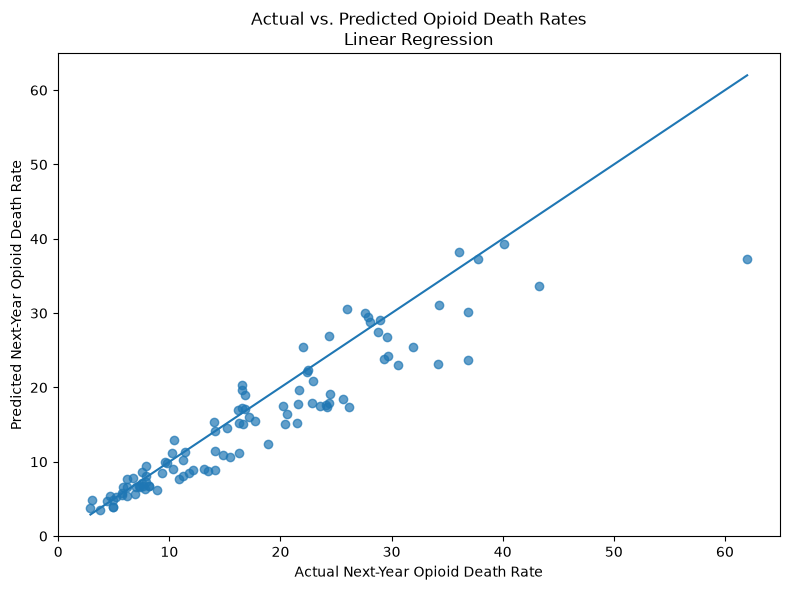

In [138]:
# Plot actual versus predicted opioid death rates
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.7
)

# Add a reference line representing perfect predictions
min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel("Actual Next-Year Opioid Death Rate")
plt.ylabel("Predicted Next-Year Opioid Death Rate")
plt.title(f"Actual vs. Predicted Opioid Death Rates\n{best_model_name}")

plt.tight_layout()
plt.show()

## Section 18. Interpret Linear Regression Coefficients
Because Linear Regression was the best-performing model, its coefficients are examined to better understand the contribution of each predictor to the model's predictions. The coefficients indicate the direction and magnitude of each predictor's relationship with the predicted next-year opioid death rate while holding the other model variables constant.

In [139]:
# Get the Linear Regression model
linear_model = models["Linear Regression"]

# Create a DataFrame of model coefficients
coefficient_df = pd.DataFrame(
    {
        "Feature": features,
        "Coefficient": linear_model.coef_,
    }
)

# Calculate absolute coefficient values for sorting
coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

# Sort features by absolute coefficient value
coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

# Display coefficients
coefficient_df

,Feature,Coefficient,Absolute_Coefficient
1,opioid_death_rate,1.084173,1.084173
2,previous_year_opioid_death_rate,-0.073631,0.073631
0,year,0.038272,0.038272


In [140]:
# Display the intercept for the Linear Regression model
if isinstance(best_model, LinearRegression):
    print("Intercept:", best_model.intercept_)

Intercept: -76.34689921580514


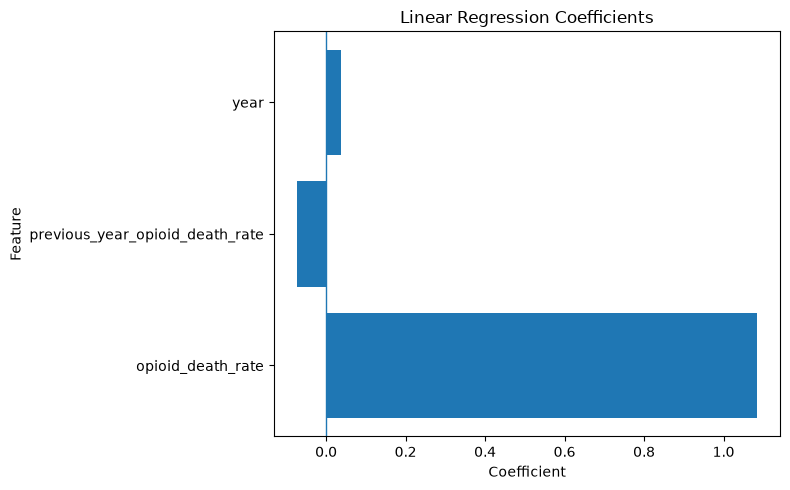

In [141]:
# Plot Linear Regression coefficients
if isinstance(best_model, LinearRegression):

    plt.figure(figsize=(8, 5))

    plt.barh(
        coefficient_df["Feature"],
        coefficient_df["Coefficient"]
    )

    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title("Linear Regression Coefficients")

    plt.axvline(
        x=0,
        linewidth=1
    )

    plt.tight_layout()
    plt.show()

## Findings:

Linear Regression was the best-performing model overall, achieving an R² of 0.826 and an MAE of 2.91 on the test set. However, performance varied substantially by target year. The mean absolute error was approximately 1.36 deaths per 100,000 for 2019 predictions compared with 4.46 for 2020 predictions. This suggests that the model captured typical year-to-year mortality patterns relatively well but had greater difficulty predicting the unusually large changes observed in 2020.